<a href="https://colab.research.google.com/github/hhk20010515/3dgs/blob/main/gaussian_splatting_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content

!git clone --recursive https://github.com/camenduru/gaussian-splatting

%cd /content/gaussian-splatting

!pip install -q ninja plyfile setuptools wheel

!pip install -q --no-build-isolation /content/gaussian-splatting/submodules/diff-gaussian-rasterization

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 31.99 MiB/s, done.
Resolving deltas: 100% (344/344), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 170), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [2]:
%cd /content/gaussian-splatting/submodules/simple-knn

!grep -q "#include <cfloat>" simple_knn.cu || sed -i '1i #include <cfloat>' simple_knn.cu

!rm -rf build *.egg-info
!pip install -q --no-build-isolation .

%cd /content/gaussian-splatting

/content/gaussian-splatting/submodules/simple-knn
  Preparing metadata (setup.py) ... done
/content/gaussian-splatting


In [3]:
import torch
from simple_knn._C import distCUDA2
print("simple_knn ok")

simple_knn ok


接入drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


导入drive图片

In [5]:
!rm -rf /content/my_scene /content/my_scene_jpg
!mkdir -p /content/my_scene/input

!cp /content/drive/MyDrive/sam3_item_extraction/cutouts/* /content/my_scene/input/

转换图片尺寸

In [6]:
from PIL import Image
from pathlib import Path

src = Path('/content/my_scene/input')
dst = Path('/content/my_scene_jpg/input')
dst.mkdir(parents=True, exist_ok=True)

count = 0

for i, p in enumerate(sorted(src.iterdir())):
    if p.suffix.lower() not in ['.png', '.jpg', '.jpeg', '.webp']:
        continue

    im = Image.open(p).convert('RGBA')
    bg = Image.new('RGBA', im.size, (255, 255, 255, 255))
    bg.alpha_composite(im)

    bg.convert('RGB').save(dst / f'{count:04d}.jpg', quality=95)
    count += 1

print("converted:", count)

converted: 33


检查转换效果

In [7]:
!ls /content/my_scene_jpg/input | head
!find /content/my_scene_jpg/input -type f | wc -l

0000.jpg
0001.jpg
0002.jpg
0003.jpg
0004.jpg
0005.jpg
0006.jpg
0007.jpg
0008.jpg
0009.jpg
33


安装colmap

In [8]:
!apt-get update -qq
!apt-get install -y colmap

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libilmbase25 libinput-bin
  libinput10 libjxr0 libmd4c0 libmetis5 libmtdev1 libopenexr25 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libraw20
  librsvg2-common libspqr2 libsuitesparseconfig5 libwacom-bin libwacom-common
  libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0
  l

转换尺寸

In [9]:
from PIL import Image
from pathlib import Path
import shutil

src = Path("/content/my_scene/input")
dst = Path("/content/cutout_uniform/input")

shutil.rmtree("/content/cutout_uniform", ignore_errors=True)
dst.mkdir(parents=True, exist_ok=True)

target_size = (1024, 1024)
count = 0

for p in sorted(src.iterdir()):
    if p.suffix.lower() not in [".png", ".jpg", ".jpeg", ".webp"]:
        continue

    im = Image.open(p).convert("RGBA")

    # 保持比例，放进统一大小的白底画布
    im.thumbnail((900, 900), Image.LANCZOS)

    canvas = Image.new("RGBA", target_size, (255, 255, 255, 255))
    x = (target_size[0] - im.width) // 2
    y = (target_size[1] - im.height) // 2
    canvas.alpha_composite(im, (x, y))

    canvas.convert("RGB").save(dst / f"{count:04d}.jpg", quality=95)
    count += 1

print("saved:", count)

saved: 33


检查尺寸

In [10]:
from PIL import Image
from pathlib import Path
from collections import Counter

sizes = Counter(Image.open(p).size for p in Path("/content/cutout_uniform/input").glob("*.jpg"))
print(sizes)

Counter({(1024, 1024): 33})


In [11]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [12]:
!rm -rf /content/cutout_uniform/colmap_try
!mkdir -p /content/cutout_uniform/colmap_try/sparse

In [13]:
!QT_QPA_PLATFORM=offscreen colmap feature_extractor \
    --database_path /content/cutout_uniform/colmap_try/database.db \
    --image_path /content/cutout_uniform/input \
    --ImageReader.single_camera 1 \
    --ImageReader.camera_model SIMPLE_RADIAL \
    --SiftExtraction.use_gpu 0 \
    --SiftExtraction.max_num_features 16384 \
    --SiftExtraction.peak_threshold 0.002 \
    --SiftExtraction.estimate_affine_shape 1 \
    --SiftExtraction.domain_size_pooling 1


Feature extraction

Processed file [1/33]
  Name:            0000.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1228.80px
  Features:        228
Processed file [2/33]
  Name:            0001.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1228.80px
  Features:        254
Processed file [3/33]
  Name:            0002.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1228.80px
  Features:        241
Processed file [4/33]
  Name:            0003.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1228.80px
  Features:        215
Processed file [5/33]
  Name:            0005.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1228.80px
  Features:        124
Processed file [6/33]
  Name:            0004.jpg
  Dimensions:      1024 x 1024
  Camera:          #1 - SIMPLE_RADIAL
  Foc

In [14]:
!QT_QPA_PLATFORM=offscreen colmap exhaustive_matcher \
    --database_path /content/cutout_uniform/colmap_try/database.db \
    --SiftMatching.use_gpu 0 \
    --SiftMatching.guided_matching 1 \
    --SiftMatching.max_ratio 0.9 \
    --SiftMatching.max_error 8


Exhaustive feature matching

Matching block [1/1, 1/1] in 11.533s
Elapsed time: 0.192 [minutes]


In [15]:
!QT_QPA_PLATFORM=offscreen colmap mapper \
    --database_path /content/cutout_uniform/colmap_try/database.db \
    --image_path /content/cutout_uniform/input \
    --output_path /content/cutout_uniform/colmap_try/sparse \
    --Mapper.init_min_num_inliers 20 \
    --Mapper.abs_pose_min_num_inliers 10 \
    --Mapper.init_min_tri_angle 2 \
    --Mapper.max_reg_trials 5 \
    --Mapper.ba_global_function_tolerance 0.000001


Loading database

Loading cameras... 1 in 0.000s
Loading matches... 132 in 0.000s
Loading images... 33 in 0.001s (connected 33)
Building correspondence graph... in 0.001s (ignored 0)

Elapsed time: 0.000 [minutes]


Finding good initial image pair


Initializing with image pair #3 and #33


Global bundle adjustment

iter      cost      cost_change  |gradient|   |step|    tr_ratio  tr_radius  ls_iter  iter_time  total_time
   0  1.761600e+02    0.00e+00    1.27e+04   0.00e+00   0.00e+00  1.00e+04        0    5.42e-04    1.43e-03
   1  1.481100e+02    2.80e+01    1.23e+03   3.43e+01   9.89e-01  3.00e+04        1    9.70e-04    2.43e-03
   2  1.602255e+02   -1.21e+01    1.23e+03   5.96e+01  -1.09e+01  1.50e+04        1    3.99e-04    2.85e-03
   3  1.488380e+02   -7.28e-01    1.23e+03   3.51e+01  -8.58e-01  3.75e+03        1    3.68e-04    3.23e-03
   4  1.475855e+02    5.25e-01    6.83e+01   1.01e+01   9.83e-01  1.12e+04        1    8.26e-04    4.07e-03
   5  1.477423e+02   -1.57e-01   

In [16]:
!find /content/cutout_uniform/colmap_try/sparse -name cameras.bin -o -name images.bin -o -name points3D.bin

/content/cutout_uniform/colmap_try/sparse/1/images.bin
/content/cutout_uniform/colmap_try/sparse/1/cameras.bin
/content/cutout_uniform/colmap_try/sparse/1/points3D.bin
/content/cutout_uniform/colmap_try/sparse/0/images.bin
/content/cutout_uniform/colmap_try/sparse/0/cameras.bin
/content/cutout_uniform/colmap_try/sparse/0/points3D.bin


In [17]:
!rm -rf /content/cutout_uniform/images /content/cutout_uniform/sparse

!QT_QPA_PLATFORM=offscreen colmap image_undistorter \
    --image_path /content/cutout_uniform/input \
    --input_path /content/cutout_uniform/colmap_try/sparse/0 \
    --output_path /content/cutout_uniform \
    --output_type COLMAP


Reading reconstruction

 => Reconstruction with 21 images and 526 points

Image undistortion

Undistorting image [1/21]
Undistorting image [2/21]
Undistorting image [3/21]
Undistorting image [4/21]
Undistorting image [5/21]
Undistorting image [6/21]
Undistorting image [7/21]
Undistorting image [8/21]
Undistorting image [9/21]
Undistorting image [10/21]
Undistorting image [11/21]
Undistorting image [12/21]
Undistorting image [13/21]
Undistorting image [14/21]
Undistorting image [15/21]
Undistorting image [16/21]
Undistorting image [17/21]
Undistorting image [18/21]
Undistorting image [19/21]
Undistorting image [20/21]
Undistorting image [21/21]
Writing reconstruction...
Writing configuration...
Writing scripts...
Elapsed time: 0.060 [minutes]


In [18]:
!mkdir -p /content/cutout_uniform/sparse/0

!mv /content/cutout_uniform/sparse/cameras.bin /content/cutout_uniform/sparse/0/
!mv /content/cutout_uniform/sparse/images.bin /content/cutout_uniform/sparse/0/
!mv /content/cutout_uniform/sparse/points3D.bin /content/cutout_uniform/sparse/0/

In [22]:
%cd /content/gaussian-splatting
!python train.py -s /content/cutout_uniform

/content/gaussian-splatting
2026-05-22 11:12:54.335015: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing 
Output folder: ./output/b6219640-9 [22/05 11:12:59]
Reading camera 21/21 [22/05 11:12:59]
Loading Training Cameras [22/05 11:12:59]
Loading Test Cameras [22/05 11:13:00]
Number of points at initialisation :  526 [22/05 11:13:00]
Training progress:  23% 7000/30000 [05:41<20:52, 18.37it/s, Loss=0.0239103]
[ITER 7000] Evaluating train: L1 0.024250126257538796 PSNR 24.41219635009766 [22/05 11:18:43]

[ITER 7000] Saving Gaussians [22/05 11:18:43]
Training progress: 100% 30000/30000 [21:09<00:00, 23.64it/s, Loss=0.0099368]

[ITER 30000] Evaluating train: L1 0.006009997613728047 PSNR 27.39471893310547 [22/05 11:34:11]

[ITER 30000] Saving 

In [24]:
%cd /content/gaussian-splatting

!python render.py -m /content/gaussian-splatting/output/b6219640-9

/content/gaussian-splatting
Looking for config file in /content/gaussian-splatting/output/b6219640-9/cfg_args
Config file found: /content/gaussian-splatting/output/b6219640-9/cfg_args
Rendering /content/gaussian-splatting/output/b6219640-9
Loading trained model at iteration 30000 [22/05 11:39:39]
Reading camera 21/21 [22/05 11:39:39]
Loading Training Cameras [22/05 11:39:39]
Loading Test Cameras [22/05 11:39:39]
Rendering progress: 100% 21/21 [00:02<00:00,  9.42it/s]
Rendering progress: 0it [00:00, ?it/s]


In [27]:
from PIL import Image
from pathlib import Path
import shutil

src = Path("/content/my_scene/input")
white_files = sorted(Path("/content/cutout_uniform/input").glob("*.jpg"))

train_scene = Path("/content/cutout_alpha_train")
dst = train_scene / "images"

shutil.rmtree(train_scene, ignore_errors=True)
dst.mkdir(parents=True, exist_ok=True)

src_files = sorted([
    p for p in src.iterdir()
    if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]
])

print("source cutouts:", len(src_files))
print("colmap white jpgs:", len(white_files))

assert len(src_files) == len(white_files), "图片数量不一致"

source cutouts: 33
colmap white jpgs: 33


In [28]:
target_size = (1024, 1024)

for src_file, white_file in zip(src_files, white_files):
    im = Image.open(src_file).convert("RGBA")

    # 要和之前 white JPG 的生成方式一致
    im.thumbnail((900, 900), Image.LANCZOS)

    # 透明区域 RGB 设成黑色，alpha=0
    canvas = Image.new("RGBA", target_size, (0, 0, 0, 0))

    x = (target_size[0] - im.width) // 2
    y = (target_size[1] - im.height) // 2
    canvas.alpha_composite(im, (x, y))

    out_name = white_file.stem + ".png"
    canvas.save(dst / out_name)

print("alpha images saved:", len(list(dst.glob("*.png"))))

alpha images saved: 33


In [29]:
!ls /content/cutout_alpha_train/images | head

0000.png
0001.png
0002.png
0003.png
0004.png
0005.png
0006.png
0007.png
0008.png
0009.png


In [30]:
!mkdir -p /content/cutout_alpha_train/sparse/0

!colmap model_converter \
    --input_path /content/cutout_uniform/sparse/0 \
    --output_path /content/cutout_alpha_train/sparse/0 \
    --output_type TXT

In [31]:
from pathlib import Path

images_txt = Path("/content/cutout_alpha_train/sparse/0/images.txt")

new_lines = []

for line in images_txt.read_text().splitlines():
    parts = line.split()

    # COLMAP images.txt 的相机行正好是 10 列，最后一列是图片名
    if len(parts) == 10 and parts[-1].lower().endswith(".jpg"):
        parts[-1] = str(Path(parts[-1]).with_suffix(".png"))
        line = " ".join(parts)

    new_lines.append(line)

images_txt.write_text("\n".join(new_lines) + "\n")

print("done")

done


In [32]:
!grep ".png" /content/cutout_alpha_train/sparse/0/images.txt | head

24 0.90676038743140297 0.23215816331325992 -0.29266529200212221 -0.19553826696986529 2.0914149377287816 -0.60479485658291121 1.4205092015926788 1 0023.png
23 0.86275512794250198 0.20792567812479082 -0.38574656870811574 -0.25223022482481738 2.7096571345920184 -1.1035957723303278 1.8932218311192173 1 0022.png
22 0.80258263424153475 0.18244179161814381 -0.4765997482935197 -0.30891550270524526 3.1747247714718383 -1.652792658782813 2.3060648112029232 1 0021.png
21 0.72171408015470762 0.156844473123885 -0.56555427035081551 -0.36698360323710927 3.3718263727310664 -2.2442707858534305 2.9131812434398303 1 0020.png
8 0.8689741852437648 0.21046899055640786 0.35950243711978191 0.26710422516133875 -2.7835806159498198 -1.6300222737542645 1.7029390196474623 1 0007.png
20 0.60410400266624342 0.1499672549295325 -0.64512740523295109 -0.44314648529456224 3.5819458846808638 -2.8725197999013647 3.5391372537078007 1 0019.png
7 0.90281852798596374 -0.027984252393850981 0.40228998527633431 0.14932633689199556

In [33]:
!find /content/cutout_alpha_train -maxdepth 4 -type f | head -20

/content/cutout_alpha_train/sparse/0/points3D.txt
/content/cutout_alpha_train/sparse/0/cameras.txt
/content/cutout_alpha_train/sparse/0/images.txt
/content/cutout_alpha_train/images/0023.png
/content/cutout_alpha_train/images/0010.png
/content/cutout_alpha_train/images/0020.png
/content/cutout_alpha_train/images/0012.png
/content/cutout_alpha_train/images/0022.png
/content/cutout_alpha_train/images/0032.png
/content/cutout_alpha_train/images/0013.png
/content/cutout_alpha_train/images/0001.png
/content/cutout_alpha_train/images/0000.png
/content/cutout_alpha_train/images/0027.png
/content/cutout_alpha_train/images/0002.png
/content/cutout_alpha_train/images/0006.png
/content/cutout_alpha_train/images/0015.png
/content/cutout_alpha_train/images/0005.png
/content/cutout_alpha_train/images/0025.png
/content/cutout_alpha_train/images/0030.png
/content/cutout_alpha_train/images/0019.png


In [39]:
%cd /content/gaussian-splatting

!python train.py \
    -s /content/cutout_alpha_train \
    -m /content/gaussian-splatting/output/cutout_alpha_30000 \
    --iterations 30000

/content/gaussian-splatting
2026-05-22 11:54:12.528890: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/gaussian-splatting/output/cutout_alpha_30000
Output folder: /content/gaussian-splatting/output/cutout_alpha_30000 [22/05 11:54:16]
Reading camera 21/21 [22/05 11:54:16]
Loading Training Cameras [22/05 11:54:16]
Loading Test Cameras [22/05 11:54:17]
Number of points at initialisation :  526 [22/05 11:54:17]
Training progress:  23% 7000/30000 [02:49<09:47, 39.17it/s, Loss=0.0023266]
[ITER 7000] Evaluating train: L1 0.0012230799533426762 PSNR 33.66446151733398 [22/05 11:57:10]

[ITER 7000] Saving Gaussians [22/05 11:57:10]
Training progress: 100% 30000/30000 [12:39<00:00, 39.52it/s, Loss=0.0014890]

[ITER 30000] Evaluating trai

In [40]:
%cd /content/gaussian-splatting

!python render.py -m /content/gaussian-splatting/output/cutout_alpha_7000
!python render.py -m /content/gaussian-splatting/output/cutout_alpha_30000

/content/gaussian-splatting
Looking for config file in /content/gaussian-splatting/output/cutout_alpha_7000/cfg_args
Config file found: /content/gaussian-splatting/output/cutout_alpha_7000/cfg_args
Rendering /content/gaussian-splatting/output/cutout_alpha_7000
Loading trained model at iteration 7000 [22/05 12:18:44]
Reading camera 21/21 [22/05 12:18:44]
Loading Training Cameras [22/05 12:18:44]
Loading Test Cameras [22/05 12:18:45]
Rendering progress: 100% 21/21 [00:01<00:00, 10.54it/s]
Rendering progress: 0it [00:00, ?it/s]
Looking for config file in /content/gaussian-splatting/output/cutout_alpha_30000/cfg_args
Config file found: /content/gaussian-splatting/output/cutout_alpha_30000/cfg_args
Rendering /content/gaussian-splatting/output/cutout_alpha_30000
Loading trained model at iteration 30000 [22/05 12:18:51]
Reading camera 21/21 [22/05 12:18:51]
Loading Training Cameras [22/05 12:18:51]
Loading Test Cameras [22/05 12:18:52]
Rendering progress: 100% 21/21 [00:01<00:00, 10.56it/s]
R

In [41]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

render_dir_7000 = Path("/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders")

imgs_7000 = sorted(render_dir_7000.glob("*.png"))
print("render count:", len(imgs_7000))
print(imgs_7000[:5])

render count: 21
[PosixPath('/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders/00000.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders/00001.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders/00002.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders/00003.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_7000/train/ours_7000/renders/00004.png')]


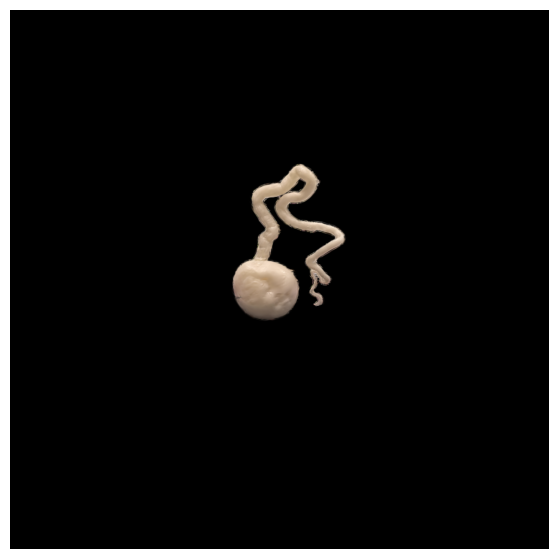

In [42]:
plt.figure(figsize=(7, 7))
plt.imshow(Image.open(imgs_7000[0]))
plt.axis("off")
plt.show()

In [43]:
render_dir_30000 = Path("/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders")

imgs_30000 = sorted(render_dir_30000.glob("*.png"))
print("render count:", len(imgs_30000))
print(imgs_30000[:5])

render count: 21
[PosixPath('/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders/00000.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders/00001.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders/00002.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders/00003.png'), PosixPath('/content/gaussian-splatting/output/cutout_alpha_30000/train/ours_30000/renders/00004.png')]


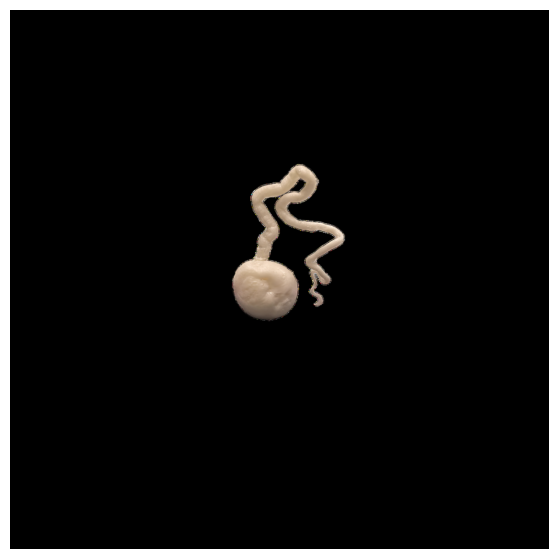

In [44]:
plt.figure(figsize=(7, 7))
plt.imshow(Image.open(imgs_30000[0]))
plt.axis("off")
plt.show()

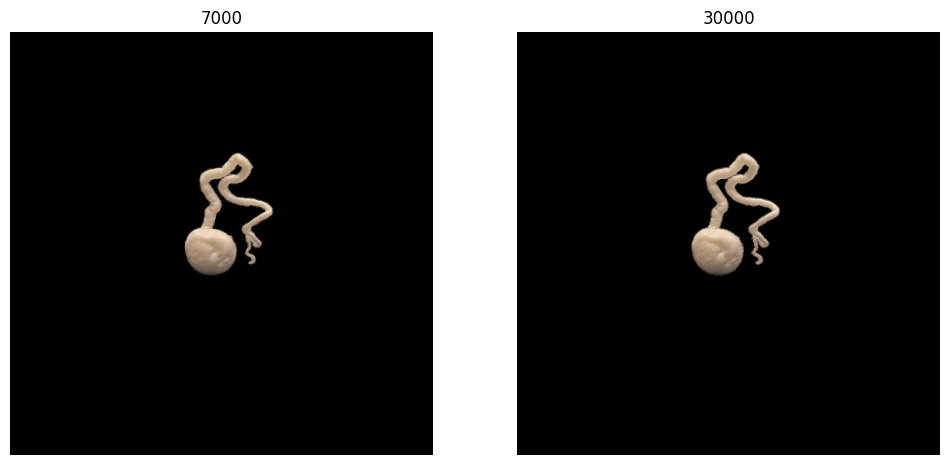

In [45]:
idx = 0

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(Image.open(imgs_7000[idx]))
ax[0].set_title("7000")
ax[0].axis("off")

ax[1].imshow(Image.open(imgs_30000[idx]))
ax[1].set_title("30000")
ax[1].axis("off")

plt.show()

IndexError: list index out of range

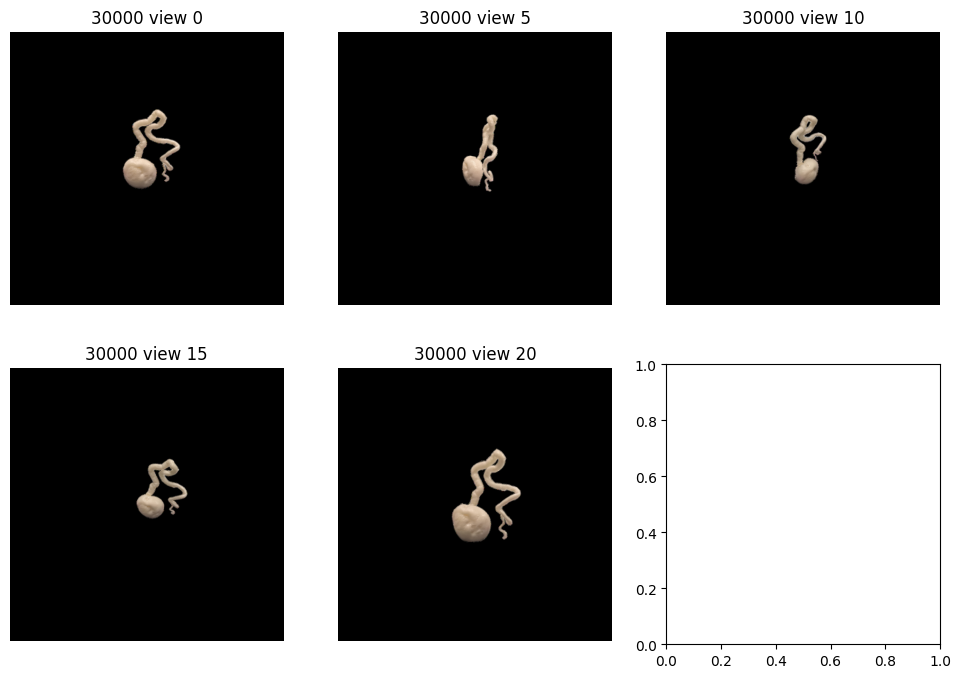

In [46]:
indices = [0, 5, 10, 15, 20, 25]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(Image.open(imgs_30000[idx]))
    ax.set_title(f"30000 view {idx}")
    ax.axis("off")

plt.show()